In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_pred = pd.read_parquet('/Users/Georgi/Dropbox/Data and AI/Group Project Supermarkets/Data files/train_params_df_20241124.parquet', engine='pyarrow')

In [3]:
df_pred.head()

,store_nbr,item_nbr,initial_alpha,initial_beta,initial_gamma,damping,alpha,beta,gamma
0,1,103520,23.085208,-0.072720,"[-8.088445423366009, -9.922224532573157, -4.80...",None,0.090888,None,1.736036e-05
1,1,105693,5.802179,0.027771,"[2.2469744746929763, 1.9399066803924618, 0.008...",None,0.600084,None,1.879713e-09
2,1,105857,48.835023,-0.096450,"[-14.42945680643002, -5.705475862794024, -10.5...",None,0.431077,None,4.207313e-06
3,1,106716,15.920897,0.053233,"[0.48760954451292615, 6.745015460185833, 2.448...",None,0.078175,None,4.050947e-10
4,1,108079,15.904189,-0.040886,"[-0.6791816056850348, -0.5095218090281307, -0....",None,0.446380,None,3.154544e-08


In [4]:
df_pred.describe()

,store_nbr,item_nbr,initial_alpha,initial_beta,alpha,gamma
count,34986.000000,3.498600e+04,34986.000000,34986.000000,3.498600e+04,3.498600e+04
mean,26.571429,1.043083e+06,25.101271,0.096443,4.107195e-01,4.792071e-03
std,16.693754,6.123195e+05,61.173463,1.221307,2.665065e-01,4.731236e-02
min,1.000000,1.035200e+05,-101.338444,-80.822300,1.490116e-08,0.000000e+00
25%,11.000000,5.078700e+05,-0.248185,-0.010659,2.041494e-01,1.359711e-09
50%,25.500000,1.012787e+06,4.475054,0.044257,3.999688e-01,2.514919e-07
75%,41.000000,1.391548e+06,27.067338,0.134787,5.876153e-01,1.000000e-04
max,54.000000,2.089339e+06,1205.293038,51.435651,1.000000e+00,1.000000e+00


In [6]:
print("Initial Beta Summary:")
print(df_pred["initial_beta"].describe())

Initial Beta Summary:
count    34986.000000
mean         0.096443
std          1.221307
min        -80.822300
25%         -0.010659
50%          0.044257
75%          0.134787
max         51.435651
Name: initial_beta, dtype: float64


In [12]:
# Analyze correlation with item_nbr
df_pred["item_nbr_log"] = np.log(df_pred["item_nbr"])  # Use log scale to detect multiplicative trends
correlation = df_pred["initial_beta"].corr(df_pred["item_nbr_log"])
print(f"Correlation between initial_beta and log(item_nbr): {correlation}")

Correlation between initial_beta and log(item_nbr): 0.046624295281198436


/Users/Georgi/Documents/Group4B/venv_case_project/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


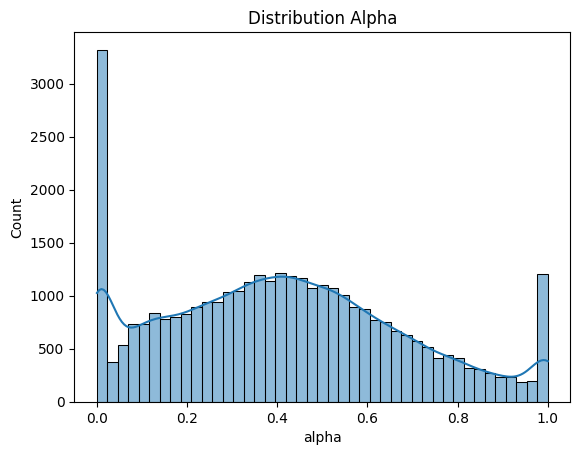

In [20]:
# Visualizing Gamma
sns.histplot(df_pred["alpha"], kde=True)
plt.title("Distribution Alpha")
plt.show()


In [27]:
# Check for missing values
missing_gamma = df_pred["gamma"].isnull().sum()
print(f"Number of missing values in gamma: {missing_gamma}")

# Summary statistics without scientific notation
pd.options.display.float_format = '{:.10f}'.format  # Set float format for the entire script
print("Gamma Column Summary (No Scientific Notation):")
print(df_pred["gamma"].describe())

# Reset the display format (optional)
pd.reset_option('display.float_format')


Number of missing values in gamma: 0
Gamma Column Summary (No Scientific Notation):
count   34986.0000000000
mean        0.0047920715
std         0.0473123591
min         0.0000000000
25%         0.0000000014
50%         0.0000002515
75%         0.0001000000
max         0.9999999851
Name: gamma, dtype: float64


/Users/Georgi/Documents/Group4B/venv_case_project/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


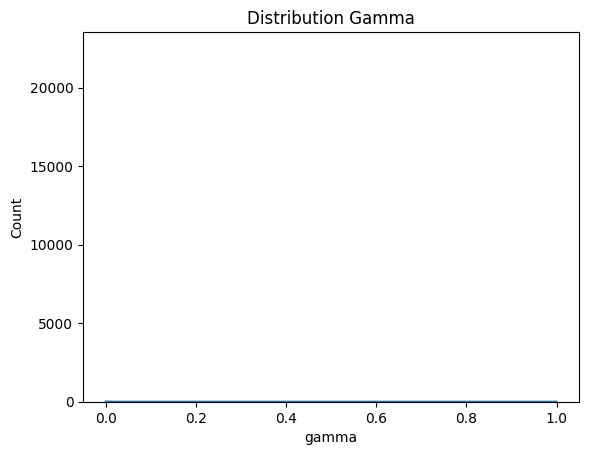

In [28]:
# Visualizing Gamma
sns.histplot(df_pred["gamma"], kde=True)
plt.title("Distribution Gamma")
plt.show()

/Users/Georgi/Documents/Group4B/venv_case_project/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


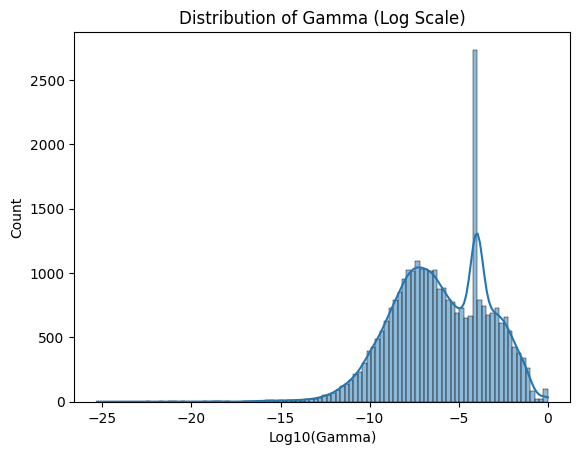

In [26]:
import numpy as np

# Replace zeros or negative values to avoid math issues
df_pred["gamma_log"] = df_pred["gamma"].apply(lambda x: np.log10(x) if x > 0 else None)
sns.histplot(df_pred["gamma_log"].dropna(), kde=True)
plt.title("Distribution of Gamma (Log Scale)")
plt.xlabel("Log10(Gamma)")
plt.show()
